In [ ]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import SVG, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.linear_model import LogisticRegression

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "bin").is_dir():
    PROJECT_DIR = PROJECT_DIR.parent

DATABASE_PATH = PROJECT_DIR / "local_data" / "ani_microbial_eukaryotes.duckdb"
if not DATABASE_PATH.is_file():
    raise FileNotFoundError(DATABASE_PATH)

FIGS_DIR = PROJECT_DIR / "assets" / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE2_SVG_PATH = FIGS_DIR / "fig-2.svg"
FIGURE2_PNG_PATH = FIGS_DIR / "fig-2.png"

PUBLICATION_FONT = "Nimbus Sans"
PLOT_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": [PUBLICATION_FONT, "Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.unicode_minus": False,
}
plt.rcParams.update(PLOT_STYLE)
sns.set_theme(style="whitegrid", font=PUBLICATION_FONT, rc=PLOT_STYLE)

RANK_ORDER = ["family-phylum", "genus", "species"]
RANK_PALETTE = {
    "species": "#0072B2",
    "genus": "#009E73",
    "family-phylum": "#CC79A7",
}
ANI_MIN, ANI_MAX = 72.5, 100.0
DISCONTINUITY_MIN, DISCONTINUITY_MAX = 80.0, 96.0
RANDOM_SEED = 2026

print(f"Analysis database: {DATABASE_PATH}")

In [2]:
con = duckdb.connect(str(DATABASE_PATH), read_only=True)
con.execute(
    f"""
    CREATE TEMP TABLE figure2_pairs AS
    SELECT genome1_id, genome2_id, ani AS ANI, 100 * af AS AF_pct,
           lca_2026_09_01 AS LCA
    FROM pairwise_metrics
    WHERE ani BETWEEN {ANI_MIN} AND {ANI_MAX}
      AND af BETWEEN 0 AND 1
      AND lca_2026_09_01 IS NOT NULL
    """
)

plot_df = con.execute(
    "SELECT ANI, AF_pct, LCA FROM figure2_pairs ORDER BY ANI"
).fetchdf()
con.close()

plot_df["rank_simple"] = np.select(
    [plot_df["LCA"].eq("species"), plot_df["LCA"].eq("genus")],
    ["species", "genus"],
    default="family-phylum",
)
plot_df["rank_simple"] = pd.Categorical(
    plot_df["rank_simple"], categories=RANK_ORDER, ordered=True
)

print(f"Figure 2 comparisons: {len(plot_df):,}")
display(plot_df["rank_simple"].value_counts(sort=False).rename("Comparisons").to_frame())

Figure 2 comparisons: 2,729,409


,Comparisons
rank_simple,
family-phylum,118156
genus,939669
species,1671584


In [3]:
# Multinomial logistic model corresponding to the original Figure 2A fit.
ani_center = plot_df["ANI"].mean()
ani_scale = plot_df["ANI"].std()
model_x = ((plot_df[["ANI"]] - ani_center) / ani_scale).to_numpy()
model_y = plot_df["rank_simple"].astype(str).to_numpy()

probability_model = LogisticRegression(
    C=1e12,
    solver="lbfgs",
    max_iter=1_000,
    random_state=RANDOM_SEED,
)
probability_model.fit(model_x, model_y)

prediction_ani = np.linspace(plot_df["ANI"].min(), plot_df["ANI"].max(), 2_000)
prediction_x = ((prediction_ani - ani_center) / ani_scale).reshape(-1, 1)
prediction_array = probability_model.predict_proba(prediction_x)
prediction_probabilities = {
    rank: prediction_array[:, np.where(probability_model.classes_ == rank)[0][0]]
    for rank in RANK_ORDER
}


def first_intersection(x, y1, y2):
    delta = y1 - y2
    indices = np.flatnonzero(np.diff(np.sign(delta)) != 0)
    if not len(indices):
        return np.nan
    i = indices[0]
    return x[i] - delta[i] * (x[i + 1] - x[i]) / (delta[i + 1] - delta[i])


intersection_left = first_intersection(
    prediction_ani,
    prediction_probabilities["genus"],
    prediction_probabilities["family-phylum"],
)
intersection_right = first_intersection(
    prediction_ani,
    prediction_probabilities["species"],
    prediction_probabilities["genus"],
)
intersections = [value for value in (intersection_left, intersection_right) if np.isfinite(value)]
print("Probability-curve intersections:", ", ".join(f"{value:.2f}%" for value in intersections))

Probability-curve intersections: 77.00%, 94.85%


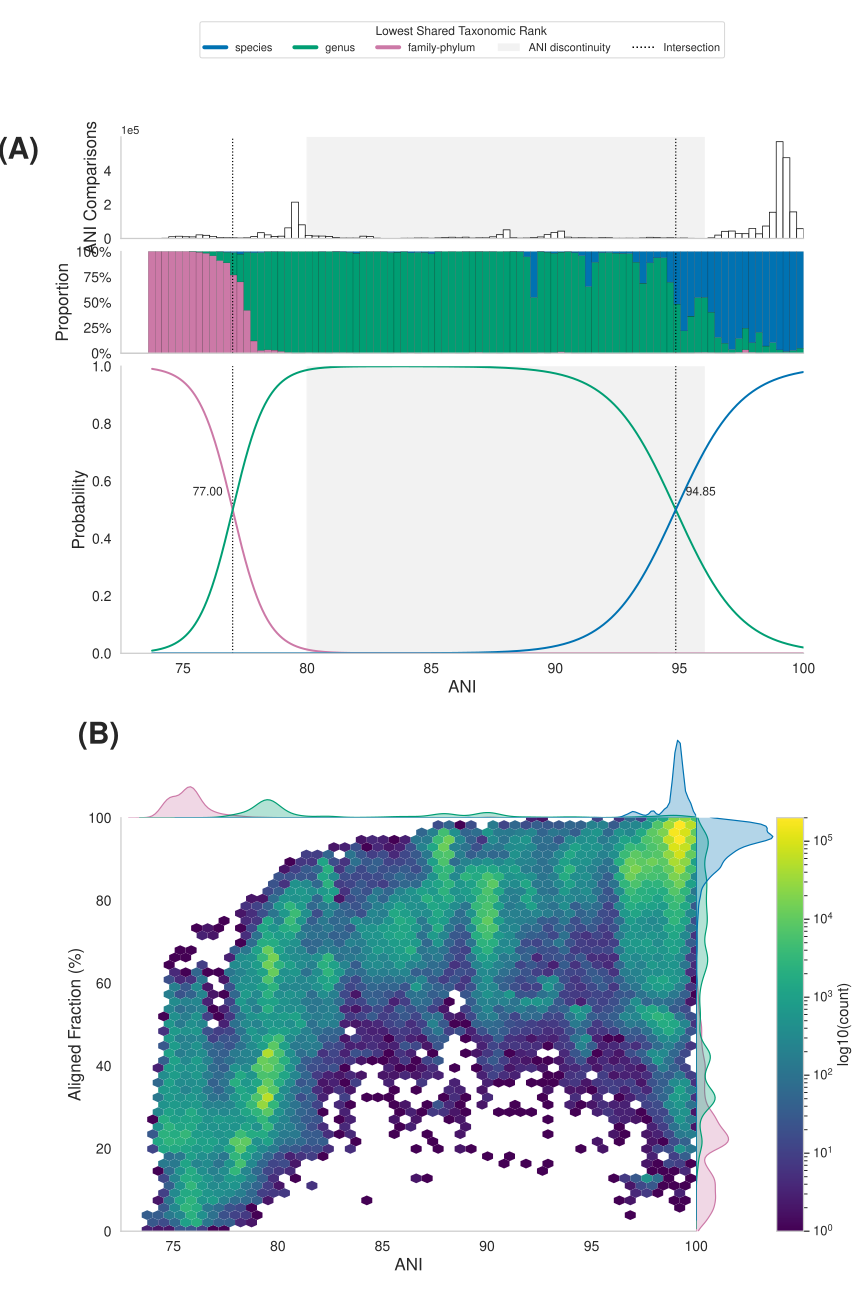

Wrote /home/.local/share/proj/ANI-microbial-eukaryotes-hetrick-2026/new_clone/ANI-microbial-eukaryotes-hetrick-2026/assets/figures/fig-2.svg
Wrote /home/.local/share/proj/ANI-microbial-eukaryotes-hetrick-2026/new_clone/ANI-microbial-eukaryotes-hetrick-2026/assets/figures/fig-2.png


In [4]:
PANEL_LABEL_SIZE = 30
AXIS_LABEL_SIZE = 17
AXIS_TICK_SIZE = 14
KDE_MAX_POINTS = 250_000


def style_axis(ax, xlabel=None, ylabel=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=AXIS_LABEL_SIZE)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=AXIS_TICK_SIZE, width=1)
    ax.grid(False)
    sns.despine(ax=ax)


fig = plt.figure(figsize=(12, 18), facecolor="white")
outer = fig.add_gridspec(3, 1, height_ratios=[0.45, 8.35, 8.0], hspace=0.24)

# Shared legend
ax_legend = fig.add_subplot(outer[0])
ax_legend.axis("off")
legend_handles = [
    Line2D([0], [0], color=RANK_PALETTE[rank], lw=4, label=rank) for rank in RANK_ORDER[::-1]
]
legend_handles.extend(
    [
        Patch(facecolor="0.85", alpha=0.35, edgecolor="none", label="ANI discontinuity"),
        Line2D([0], [0], color="black", lw=1.5, linestyle=":", label="Intersection"),
    ]
)
ax_legend.legend(
    handles=legend_handles, loc="center", ncol=5, frameon=True, title="Lowest Shared Taxonomic Rank"
)

# Panel A: counts, binned rank proportions, and multinomial probabilities
panel_a = outer[1].subgridspec(3, 1, height_ratios=[1.15, 1.15, 3.25], hspace=0.08)
ax_hist = fig.add_subplot(panel_a[0])
ax_prop = fig.add_subplot(panel_a[1], sharex=ax_hist)
ax_prob = fig.add_subplot(panel_a[2], sharex=ax_hist)
bins = np.linspace(ANI_MIN, ANI_MAX, 101)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = np.diff(bins)

for ax in (ax_hist, ax_prop, ax_prob):
    ax.axvspan(DISCONTINUITY_MIN, DISCONTINUITY_MAX, color="0.85", alpha=0.35, zorder=0)
    for value in intersections:
        ax.axvline(value, color="black", linestyle=":", linewidth=1.2)
    ax.set_xlim(ANI_MIN, ANI_MAX)

ax_hist.hist(plot_df["ANI"], bins=bins, facecolor="white", edgecolor="black", linewidth=0.7)
ax_hist.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
style_axis(ax_hist, ylabel="ANI Comparisons")
ax_hist.tick_params(labelbottom=False)

rank_counts = {
    rank: np.histogram(plot_df.loc[plot_df["rank_simple"] == rank, "ANI"], bins=bins)[0]
    for rank in RANK_ORDER
}
total_counts = np.sum(np.vstack(list(rank_counts.values())), axis=0)
bottom = np.zeros_like(total_counts, dtype=float)
for rank in RANK_ORDER:
    proportions = np.divide(
        rank_counts[rank], total_counts, out=np.zeros_like(bottom), where=total_counts > 0
    )
    ax_prop.bar(
        bin_centers, proportions, width=bin_width, bottom=bottom, align="center",
        color=RANK_PALETTE[rank], edgecolor="black", linewidth=0.15,
    )
    bottom += proportions
ax_prop.set_ylim(0, 1)
ax_prop.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax_prop.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
style_axis(ax_prop, ylabel="Proportion")
ax_prop.tick_params(labelbottom=False)

for rank in RANK_ORDER:
    ax_prob.plot(
        prediction_ani, prediction_probabilities[rank], color=RANK_PALETTE[rank], lw=2, label=rank
    )
ax_prob.set_ylim(0, 1)
ax_prob.set_xticks(np.arange(75, 101, 5))
for value, offset in ((intersection_left, -0.4), (intersection_right, 0.4)):
    if np.isfinite(value):
        ax_prob.annotate(f"{value:.2f}", (value + offset, 0.55), ha="right" if offset < 0 else "left")
style_axis(ax_prob, xlabel="ANI", ylabel="Probability")
ax_hist.text(
    -0.12, 1.0, "(A)", transform=ax_hist.transAxes,
    fontsize=PANEL_LABEL_SIZE, fontweight="bold", ha="right", va="top",
    clip_on=False,
)

# Panel B: ANI/AF hexbin with marginal distributions
panel_b = outer[2].subgridspec(2, 3, width_ratios=[7.5, 1.05, 0.35], height_ratios=[1.15, 5.85], hspace=0, wspace=0)
ax_marg_x = fig.add_subplot(panel_b[0, 0])
ax_joint = fig.add_subplot(panel_b[1, 0], sharex=ax_marg_x)
ax_marg_y = fig.add_subplot(panel_b[1, 1], sharey=ax_joint)
ax_cbar = fig.add_subplot(panel_b[1, 2])
hb = ax_joint.hexbin(
    plot_df["ANI"], plot_df["AF_pct"], gridsize=50, cmap="viridis", mincnt=1, bins="log", linewidths=0
)
for rank in RANK_ORDER:
    subset = plot_df.loc[plot_df["rank_simple"] == rank]
    if len(subset) > KDE_MAX_POINTS:
        subset = subset.sample(KDE_MAX_POINTS, random_state=RANDOM_SEED)
    sns.kdeplot(data=subset, x="ANI", fill=True, alpha=0.30, color=RANK_PALETTE[rank], lw=1.2, ax=ax_marg_x, warn_singular=False)
    sns.kdeplot(data=subset, y="AF_pct", fill=True, alpha=0.30, color=RANK_PALETTE[rank], lw=1.2, ax=ax_marg_y, warn_singular=False)
ax_joint.set_xlim(ANI_MIN, ANI_MAX)
ax_joint.set_ylim(0, 100)
ax_joint.set_xticks(np.arange(75, 101, 5))
style_axis(ax_joint, xlabel="ANI", ylabel="Aligned Fraction (%)")
for ax in (ax_marg_x, ax_marg_y):
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    sns.despine(ax=ax, left=True, bottom=True)
cbar = fig.colorbar(hb, cax=ax_cbar)
cbar.set_label("log10(count)", fontsize=15)
cbar.ax.tick_params(labelsize=13)
ax_marg_x.text(-0.075, 1.18, "(B)", transform=ax_marg_x.transAxes, fontsize=PANEL_LABEL_SIZE, fontweight="bold", va="top")

fig.subplots_adjust(left=0.14, right=0.93, top=0.98, bottom=0.05)
fig.savefig(FIGURE2_SVG_PATH, format="svg", facecolor="white", metadata={"Date": None})
fig.savefig(FIGURE2_PNG_PATH, format="png", dpi=300, facecolor="white")
plt.close(fig)
display(SVG(filename=str(FIGURE2_SVG_PATH)))
print(f"Wrote {FIGURE2_SVG_PATH}")
print(f"Wrote {FIGURE2_PNG_PATH}")